# Module 6: Practical Computer Vision Exercises
Strict implementation of all 36 exercises following the exact specifications in the documentation.


### Suggested Setup & Dataset Preparation

In [1]:
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.transforms import functional as F
from torchvision.transforms import RandomAffine, RandomResizedCrop, ColorJitter, GaussianBlur, RandomPerspective
import torchvision.transforms as T
from sklearn.metrics import confusion_matrix
import torchvision

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['image.cmap'] = 'gray'

# Extract a sample pet image from Oxford-IIIT Pet dataset and save as image.jpg
pet_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', download=False)
sample_img, _ = pet_dataset[10]
sample_img.save("image.jpg")

# Load MNIST dataset for CNN experiments
mnist_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=False, transform=T.ToTensor())
mnist_sample_img, mnist_sample_label = mnist_dataset[0]  # Shape: (1, 28, 28)
mnist_input = mnist_sample_img.unsqueeze(0)  # Shape: (1, 1, 28, 28)

print("Setup completed:")
print(f"  - Oxford-IIIT Pet sample saved to 'image.jpg'")
print(f"  - MNIST dataset loaded (Sample Digit: {mnist_sample_label}, Tensor Shape: {mnist_input.shape})")


Setup completed:
  - Oxford-IIIT Pet sample saved to 'image.jpg'
  - MNIST dataset loaded (Sample Digit: 5, Tensor Shape: torch.Size([1, 1, 28, 28]))


### Exercise 1 - Inspect Image as Numbers

In [2]:
from PIL import Image
import numpy as np

img = Image.open("image.jpg").convert("L")
arr = np.array(img)

print(arr.shape)
print(arr[:5, :5])
print(arr.min(), arr.max())


(500, 375)
[[11 11 11 11 11]
 [11 11 11 11 11]
 [11 11 11 11 11]
 [11 11 11 11 11]
 [11 11 11 11 11]]
0 246


### Exercise 2 - Build a Vertical Edge Detector

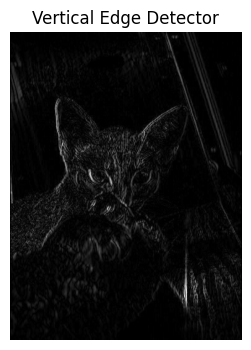

In [3]:
import cv2

kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

edges = cv2.filter2D(arr, cv2.CV_32F, kernel)

plt.imshow(np.abs(edges), cmap='gray')
plt.title("Vertical Edge Detector")
plt.axis('off')
plt.show()


### Exercise 3 - Design a Horizontal Edge Detector

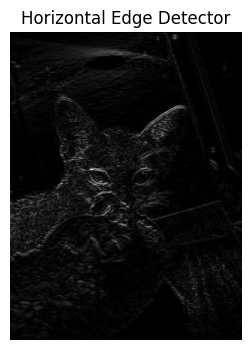

In [4]:
kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

edges_h = cv2.filter2D(arr, cv2.CV_32F, kernel)

plt.imshow(np.abs(edges_h), cmap='gray')
plt.title("Horizontal Edge Detector")
plt.axis('off')
plt.show()


### Exercise 4 - Sobel X and Sobel Y

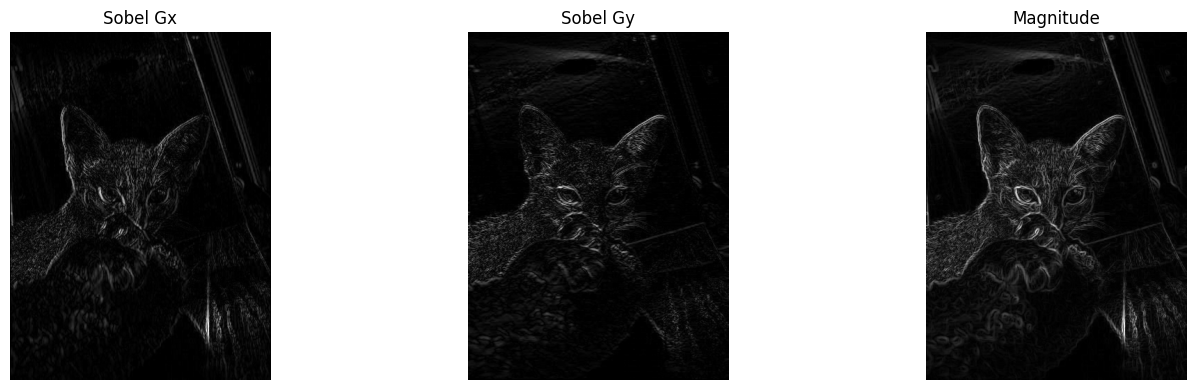

In [5]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

gx = cv2.filter2D(arr, cv2.CV_32F, sobel_x)
gy = cv2.filter2D(arr, cv2.CV_32F, sobel_y)
magnitude = np.sqrt(gx**2 + gy**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(np.abs(gx), cmap='gray')
axes[0].set_title("Sobel Gx")
axes[0].axis('off')

axes[1].imshow(np.abs(gy), cmap='gray')
axes[1].set_title("Sobel Gy")
axes[1].axis('off')

axes[2].imshow(magnitude, cmap='gray')
axes[2].set_title("Magnitude")
axes[2].axis('off')
plt.tight_layout()
plt.show()


### Exercise 5 - Blur with an Averaging Kernel

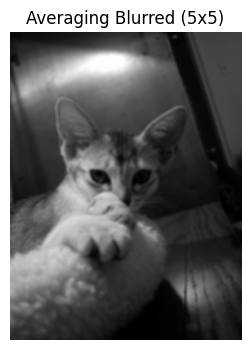

In [6]:
blur_kernel = np.ones((5, 5)) / 25
blurred = cv2.filter2D(arr, -1, blur_kernel)

plt.imshow(blurred, cmap='gray')
plt.title("Averaging Blurred (5x5)")
plt.axis('off')
plt.show()


### Exercise 6 - Gaussian Blur + Canny

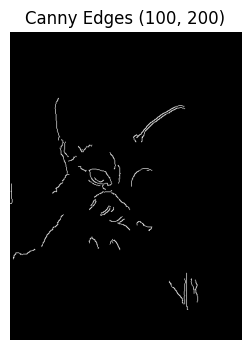

In [7]:
blurred = cv2.GaussianBlur(arr, (5, 5), 0)
edges = cv2.Canny(blurred, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edges (100, 200)")
plt.axis('off')
plt.show()


### Exercise 7 - Sharpen an Image

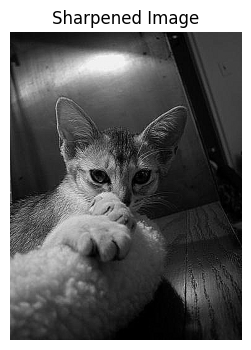

In [8]:
kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

sharp = cv2.filter2D(arr, -1, kernel)

plt.imshow(sharp, cmap='gray')
plt.title("Sharpened Image")
plt.axis('off')
plt.show()


### Exercise 8 - Inspect RGB Channels

In [9]:
img_rgb = np.array(Image.open("image.jpg").convert("RGB"))
print(img_rgb.shape)
print(img_rgb[100, 100])


(500, 375, 3)
[116 106  97]


### Exercise 9 - Convert RGB to HSV

In [10]:
bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

print("HSV Shape:", hsv.shape)


HSV Shape: (500, 375, 3)


### Exercise 10 - Detect Green Objects with a Mask

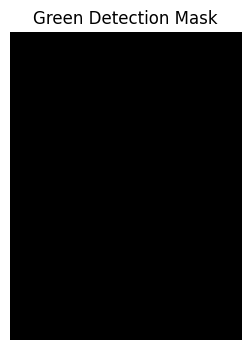

In [11]:
lower = np.array([35, 50, 50])
upper = np.array([85, 255, 255])
mask = cv2.inRange(hsv, lower, upper)

plt.imshow(mask, cmap='gray')
plt.title("Green Detection Mask")
plt.axis('off')
plt.show()


### Exercise 11 - Horizontal Flip Augmentation

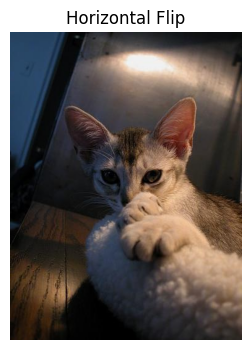

In [12]:
from torchvision.transforms import functional as F

img = Image.open("image.jpg")
flipped = F.hflip(img)

plt.imshow(flipped)
plt.title("Horizontal Flip")
plt.axis('off')
plt.show()


### Exercise 12 - Vertical Flip

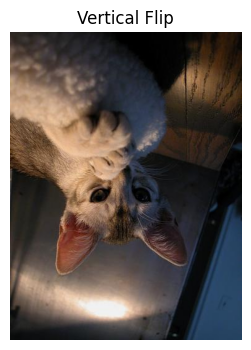

In [13]:
vertical = F.vflip(img)

plt.imshow(vertical)
plt.title("Vertical Flip")
plt.axis('off')
plt.show()


### Exercise 13 - Rotation

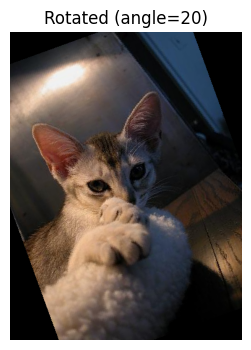

In [14]:
rotated = F.rotate(img, angle=20)

plt.imshow(rotated)
plt.title("Rotated (angle=20)")
plt.axis('off')
plt.show()


### Exercise 14 - Translation

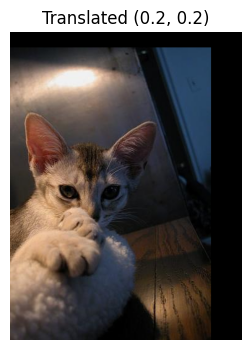

In [15]:
from torchvision.transforms import RandomAffine

move = RandomAffine(degrees=0, translate=(0.2, 0.2))
moved = move(img)

plt.imshow(moved)
plt.title("Translated (0.2, 0.2)")
plt.axis('off')
plt.show()


### Exercise 15 - Scale

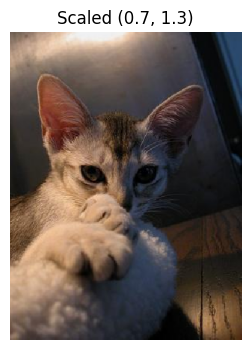

In [16]:
scale = RandomAffine(degrees=0, scale=(0.7, 1.3))
scaled = scale(img)

plt.imshow(scaled)
plt.title("Scaled (0.7, 1.3)")
plt.axis('off')
plt.show()


### Exercise 16 - Random Crop

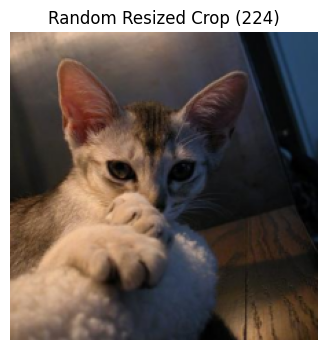

In [17]:
from torchvision.transforms import RandomResizedCrop

crop = RandomResizedCrop(224, scale=(0.6, 1.0))
cropped = crop(img)

plt.imshow(cropped)
plt.title("Random Resized Crop (224)")
plt.axis('off')
plt.show()


### Exercise 17 - Brightness Augmentation

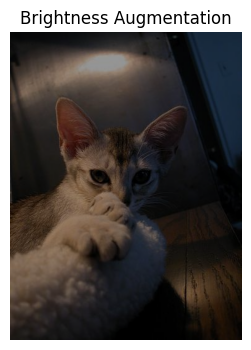

In [18]:
from torchvision.transforms import ColorJitter

change = ColorJitter(brightness=0.5)
changed = change(img)

plt.imshow(changed)
plt.title("Brightness Augmentation")
plt.axis('off')
plt.show()


### Exercise 18 - Contrast Augmentation

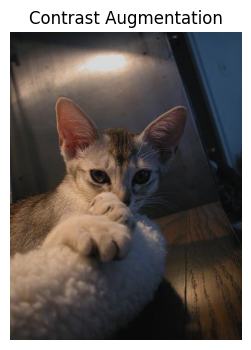

In [19]:
change = ColorJitter(contrast=0.5)
changed = change(img)

plt.imshow(changed)
plt.title("Contrast Augmentation")
plt.axis('off')
plt.show()


### Exercise 19 - Saturation Augmentation

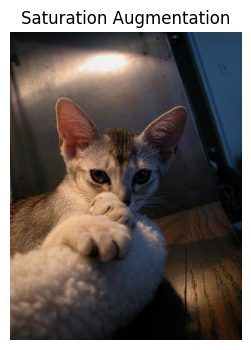

In [20]:
change = ColorJitter(saturation=0.5)
changed = change(img)

plt.imshow(changed)
plt.title("Saturation Augmentation")
plt.axis('off')
plt.show()


### Exercise 20 - Hue Augmentation

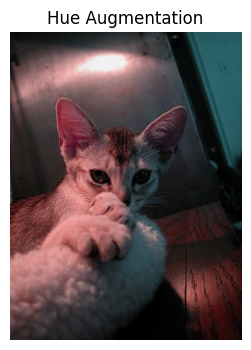

In [21]:
change = ColorJitter(hue=0.1)
changed = change(img)

plt.imshow(changed)
plt.title("Hue Augmentation")
plt.axis('off')
plt.show()


### Exercise 21 - Blur as Augmentation

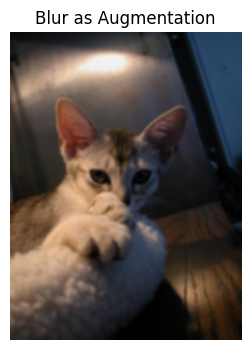

In [22]:
from torchvision.transforms import GaussianBlur

blur = GaussianBlur(kernel_size=7, sigma=(0.1, 3))
changed = blur(img)

plt.imshow(changed)
plt.title("Blur as Augmentation")
plt.axis('off')
plt.show()


### Exercise 22 - Perspective Distortion

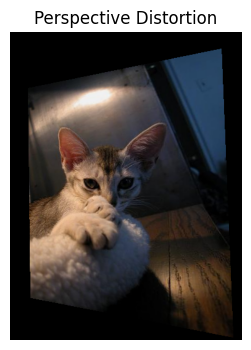

In [23]:
from torchvision.transforms import RandomPerspective

perspective = RandomPerspective(distortion_scale=0.4, p=1)
changed = perspective(img)

plt.imshow(changed)
plt.title("Perspective Distortion")
plt.axis('off')
plt.show()


### Exercise 23 - Random Erasing / Occlusion

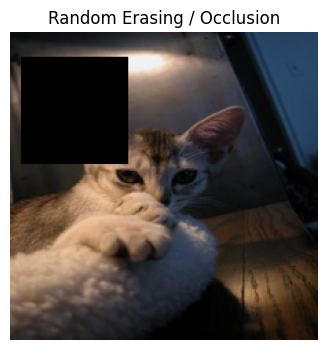

In [24]:
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.RandomErasing(p=1, scale=(0.05, 0.2))
])
changed = transform(img)

plt.imshow(changed.permute(1, 2, 0).numpy())
plt.title("Random Erasing / Occlusion")
plt.axis('off')
plt.show()


### Exercise 24 - Combine Augmentations

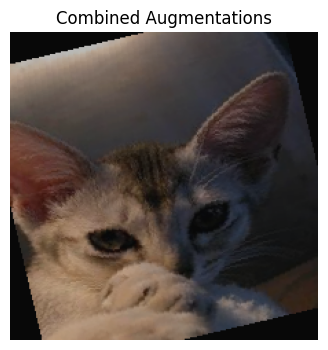

In [25]:
augment = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomPerspective(distortion_scale=0.2, p=0.3)
])

plt.imshow(augment(img))
plt.title("Combined Augmentations")
plt.axis('off')
plt.show()


### Exercise 25 - Design an Augmentation Policy

In [26]:
# For your chosen task mark each as:
# YES / NO / MAYBE
# horizontal flip, vertical flip, rotation, crop, translation,
# scale, brightness, contrast, saturation, hue, blur,
# perspective, random erasing

policy = {
    "horizontal flip": "YES",
    "vertical flip": "NO",
    "rotation": "YES",
    "crop": "YES",
    "translation": "YES",
    "scale": "YES",
    "brightness": "YES",
    "contrast": "YES",
    "saturation": "YES",
    "hue": "NO",
    "blur": "MAYBE",
    "perspective": "MAYBE",
    "random erasing": "YES"
}

for k, v in policy.items():
    print(f"{k:<18}: {v}")


horizontal flip   : YES
vertical flip     : NO
rotation          : YES
crop              : YES
translation       : YES
scale             : YES
brightness        : YES
contrast          : YES
saturation        : YES
hue               : NO
blur              : MAYBE
perspective       : MAYBE
random erasing    : YES


### Exercise 26 - Create a Learnable Convolution

Weight Tensor Shape: torch.Size([8, 1, 3, 3]) (out_channels, in_channels, k_h, k_w)
Bias Tensor Shape:   torch.Size([8])


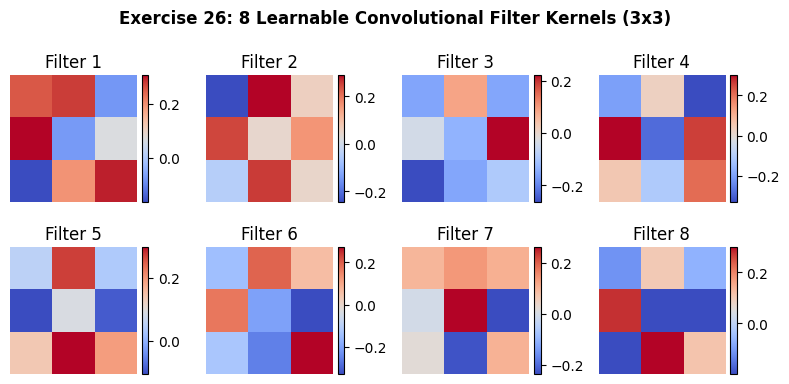

In [27]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3)
print(f"Weight Tensor Shape: {conv.weight.shape} (out_channels, in_channels, k_h, k_w)")
print(f"Bias Tensor Shape:   {conv.bias.shape}")

# Visualize the 8 initialized learnable 3x3 filter kernels
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    kernel = conv.weight[i, 0].detach().numpy()
    im = ax.imshow(kernel, cmap='coolwarm')
    ax.set_title(f"Filter {i+1}")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Exercise 26: 8 Learnable Convolutional Filter Kernels (3x3)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Exercise 27 - Pass Data Through Convolution

Input shape:        torch.Size([1, 1, 28, 28])
Conv output shape:  torch.Size([1, 8, 26, 26])  [W_out = (28 - 3)/1 + 1 = 26]


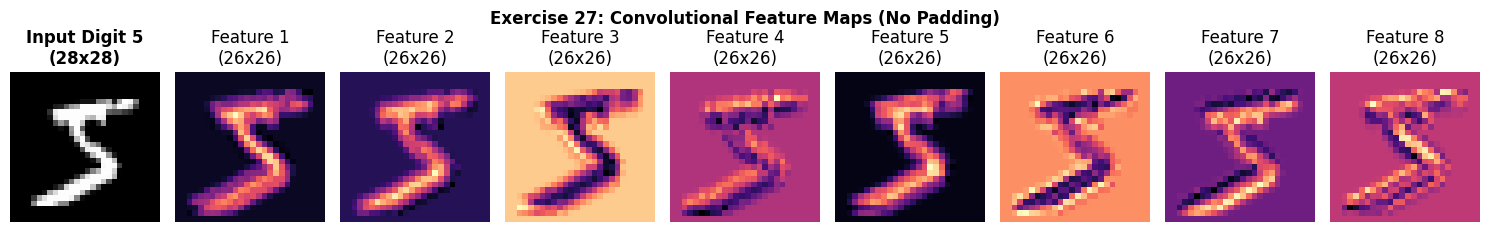

In [28]:
# Pass MNIST data through convolution without padding
torch.manual_seed(42)
conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3)
x = mnist_input  # (1, 1, 28, 28)
y = conv(x)

print(f"Input shape:        {x.shape}")
print(f"Conv output shape:  {y.shape}  [W_out = (28 - 3)/1 + 1 = 26]")

# Visualize input digit and the 8 output feature maps
fig, axes = plt.subplots(1, 9, figsize=(15, 2.5))
axes[0].imshow(x.squeeze().numpy(), cmap='gray')
axes[0].set_title(f"Input Digit {mnist_sample_label}\n(28x28)", fontweight='bold')
axes[0].axis('off')

for i in range(8):
    feat = y[0, i].detach().numpy()
    axes[i+1].imshow(feat, cmap='magma')
    axes[i+1].set_title(f"Feature {i+1}\n(26x26)")
    axes[i+1].axis('off')

plt.suptitle("Exercise 27: Convolutional Feature Maps (No Padding)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Exercise 28 - Padding

Input shape:         torch.Size([1, 1, 28, 28])
Padded output shape: torch.Size([1, 8, 28, 28])  [W_out = (28 - 3 + 2)/1 + 1 = 28]


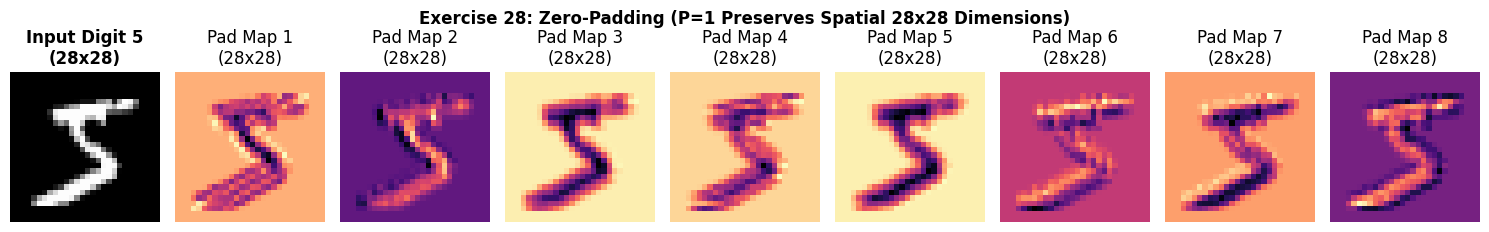

In [29]:
# Padded convolution preserving boundary dimensions
conv_padded = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
y_padded = conv_padded(x)

print(f"Input shape:         {x.shape}")
print(f"Padded output shape: {y_padded.shape}  [W_out = (28 - 3 + 2)/1 + 1 = 28]")

# Visualize boundary-preserved feature maps
fig, axes = plt.subplots(1, 9, figsize=(15, 2.5))
axes[0].imshow(x.squeeze().numpy(), cmap='gray')
axes[0].set_title(f"Input Digit {mnist_sample_label}\n(28x28)", fontweight='bold')
axes[0].axis('off')

for i in range(8):
    feat = y_padded[0, i].detach().numpy()
    axes[i+1].imshow(feat, cmap='magma')
    axes[i+1].set_title(f"Pad Map {i+1}\n(28x28)")
    axes[i+1].axis('off')

plt.suptitle("Exercise 28: Zero-Padding (P=1 Preserves Spatial 28x28 Dimensions)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Exercise 29 - Stride

Input shape:          torch.Size([1, 1, 28, 28])
Strided output shape: torch.Size([1, 8, 14, 14])  [W_out = floor((28 - 3 + 2)/2) + 1 = 14]


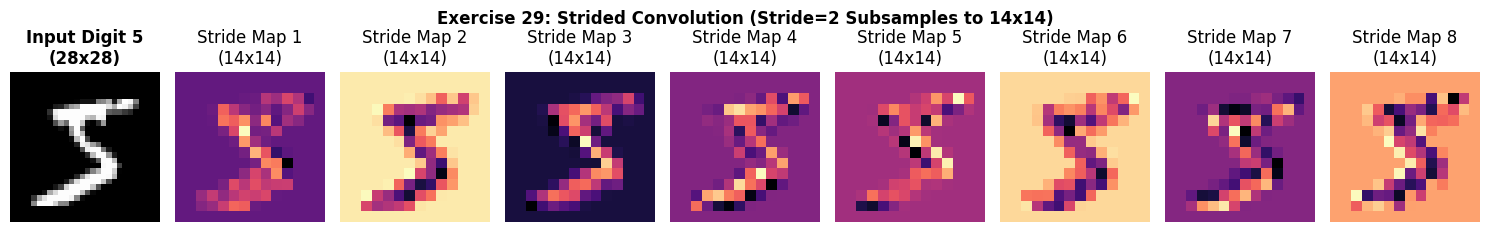

In [30]:
# Strided convolution for spatial downsampling
conv_strided = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=2, padding=1)
y_strided = conv_strided(x)

print(f"Input shape:          {x.shape}")
print(f"Strided output shape: {y_strided.shape}  [W_out = floor((28 - 3 + 2)/2) + 1 = 14]")

# Visualize downsampled feature maps
fig, axes = plt.subplots(1, 9, figsize=(15, 2.5))
axes[0].imshow(x.squeeze().numpy(), cmap='gray')
axes[0].set_title(f"Input Digit {mnist_sample_label}\n(28x28)", fontweight='bold')
axes[0].axis('off')

for i in range(8):
    feat = y_strided[0, i].detach().numpy()
    axes[i+1].imshow(feat, cmap='magma')
    axes[i+1].set_title(f"Stride Map {i+1}\n(14x14)")
    axes[i+1].axis('off')

plt.suptitle("Exercise 29: Strided Convolution (Stride=2 Subsamples to 14x14)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Exercise 30 - ReLU

Numerical test: Input [-5.0, -2.0, 0.0, 2.0, 8.0] -> ReLU [0.0, 0.0, 0.0, 2.0, 8.0]


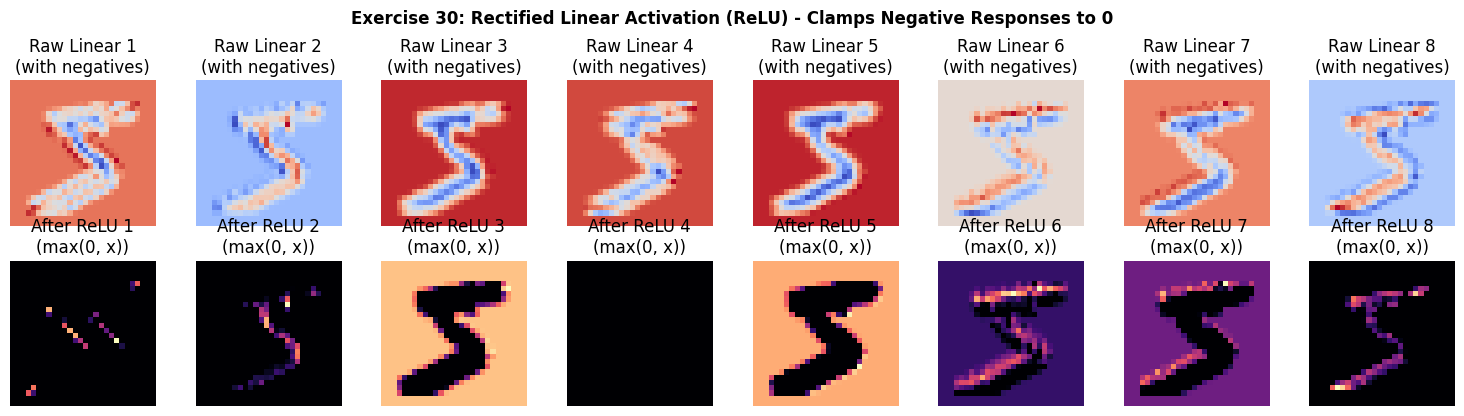

In [31]:
relu = nn.ReLU()
num_test = torch.tensor([-5., -2., 0., 2., 8.])
print(f"Numerical test: Input {num_test.tolist()} -> ReLU {relu(num_test).tolist()}")

# Apply ReLU to convolution feature maps
raw_features = conv_padded(x)
relu_features = relu(raw_features)

fig, axes = plt.subplots(2, 8, figsize=(15, 4.2))
for i in range(8):
    axes[0, i].imshow(raw_features[0, i].detach().numpy(), cmap='coolwarm')
    axes[0, i].set_title(f"Raw Linear {i+1}\n(with negatives)")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(relu_features[0, i].detach().numpy(), cmap='magma')
    axes[1, i].set_title(f"After ReLU {i+1}\n(max(0, x))")
    axes[1, i].axis('off')

plt.suptitle("Exercise 30: Rectified Linear Activation (ReLU) - Clamps Negative Responses to 0", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Exercise 31 - Max Pooling

Numerical 4x4 MaxPool (2x2):
tensor([[[[9., 8.],
          [8., 6.]]]])

Feature Map Pooling: Pre-Pool torch.Size([1, 8, 28, 28]) -> Post-Pool torch.Size([1, 8, 14, 14])


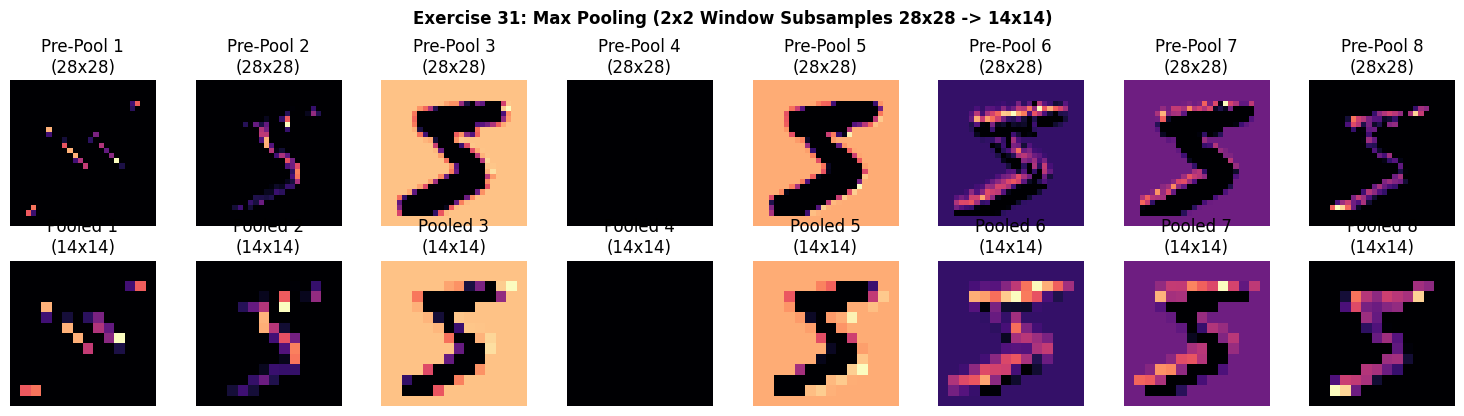

In [32]:
# 1. 2D Tensor MaxPool demonstration
matrix_sample = torch.tensor([[[[1., 2., 3., 4.],
                                [5., 9., 7., 8.],
                                [2., 3., 4., 1.],
                                [8., 2., 1., 6.]]]])
pool = nn.MaxPool2d(2)
print("Numerical 4x4 MaxPool (2x2):")
print(pool(matrix_sample))

# 2. MaxPool on MNIST activation maps
pooled_features = pool(relu_features)
print(f"\nFeature Map Pooling: Pre-Pool {relu_features.shape} -> Post-Pool {pooled_features.shape}")

fig, axes = plt.subplots(2, 8, figsize=(15, 4.2))
for i in range(8):
    axes[0, i].imshow(relu_features[0, i].detach().numpy(), cmap='magma')
    axes[0, i].set_title(f"Pre-Pool {i+1}\n(28x28)")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(pooled_features[0, i].detach().numpy(), cmap='magma')
    axes[1, i].set_title(f"Pooled {i+1}\n(14x14)")
    axes[1, i].axis('off')

plt.suptitle("Exercise 31: Max Pooling (2x2 Window Subsamples 28x28 -> 14x14)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Exercise 32 - Build a Tiny CNN

Tiny CNN Architecture:
Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=10, bias=True)
)


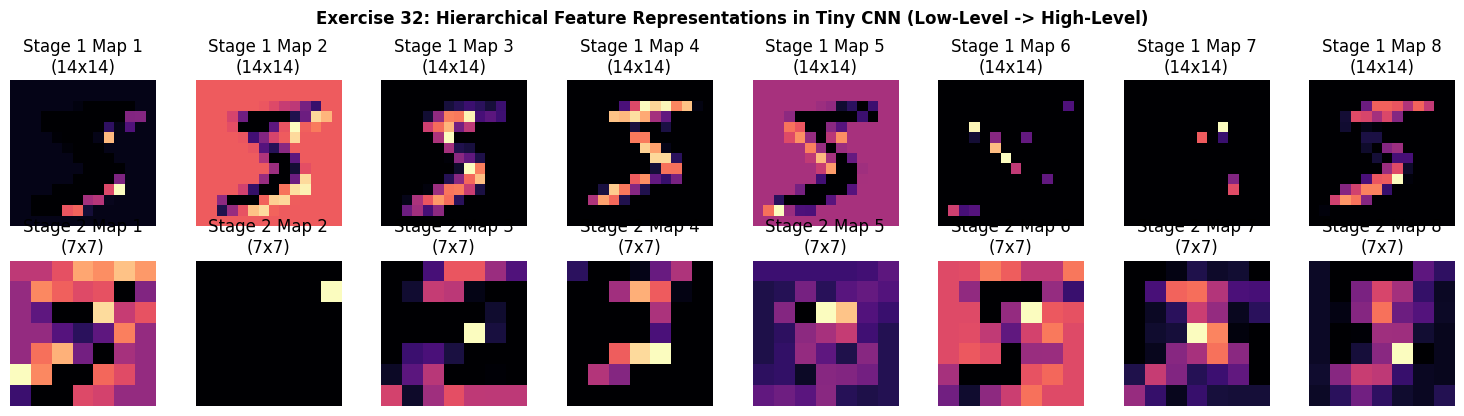

In [33]:
# Construct Tiny CNN architecture for MNIST digit classification
model = nn.Sequential(
    nn.Conv2d(1, 16, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * 7 * 7, 10)
)
print("Tiny CNN Architecture:")
print(model)

# Forward pass layer-by-layer to extract intermediate feature activations
with torch.no_grad():
    s1_conv = model[0](x)
    s1_relu = model[1](s1_conv)
    s1_pool = model[2](s1_relu)  # [1, 16, 14, 14]
    s2_conv = model[3](s1_pool)
    s2_relu = model[4](s2_conv)
    s2_pool = model[5](s2_relu)  # [1, 32, 7, 7]

fig, axes = plt.subplots(2, 8, figsize=(15, 4.2))
for i in range(8):
    axes[0, i].imshow(s1_pool[0, i].numpy(), cmap='magma')
    axes[0, i].set_title(f"Stage 1 Map {i+1}\n(14x14)")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(s2_pool[0, i].numpy(), cmap='magma')
    axes[1, i].set_title(f"Stage 2 Map {i+1}\n(7x7)")
    axes[1, i].axis('off')

plt.suptitle("Exercise 32: Hierarchical Feature Representations in Tiny CNN (Low-Level -> High-Level)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Exercise 33 - Classification Output

Logits output shape: torch.Size([1, 10])
Unnormalized logits: [-0.025 -0.032  0.038 -0.018 -0.093 -0.013  0.011 -0.041 -0.103 -0.063]
Softmax probabilities sum: 1.0000


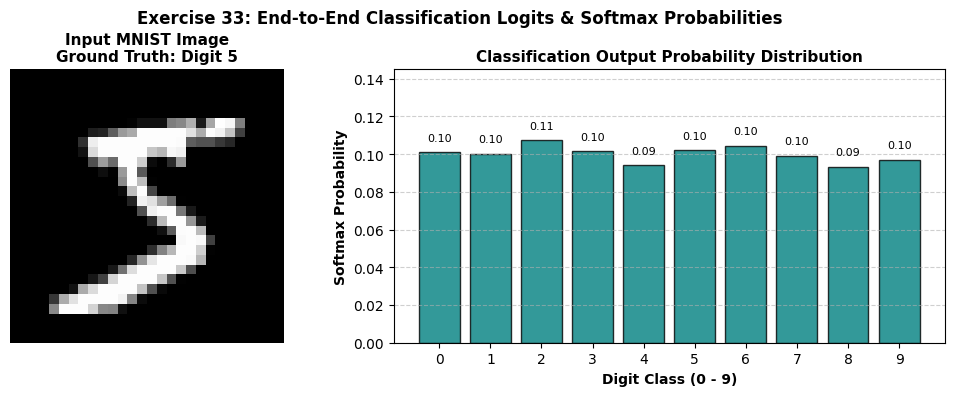

In [34]:
# Forward pass MNIST sample through Tiny CNN to compute classification output
with torch.no_grad():
    logits = model(x)
    probabilities = torch.softmax(logits, dim=1).squeeze().numpy()

print(f"Logits output shape: {logits.shape}")
print(f"Unnormalized logits: {logits[0].numpy().round(3)}")
print(f"Softmax probabilities sum: {probabilities.sum():.4f}")

# Visualize input digit alongside predicted class probabilities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1.6]})

ax1.imshow(x.squeeze().numpy(), cmap='gray')
ax1.set_title(f"Input MNIST Image\nGround Truth: Digit {mnist_sample_label}", fontsize=11, fontweight='bold')
ax1.axis('off')

bars = ax2.bar(range(10), probabilities, color='teal', alpha=0.8, edgecolor='black')
ax2.set_xticks(range(10))
ax2.set_xlabel("Digit Class (0 - 9)", fontweight='bold')
ax2.set_ylabel("Softmax Probability", fontweight='bold')
ax2.set_title("Classification Output Probability Distribution", fontsize=11, fontweight='bold')
ax2.set_ylim(0, max(probabilities) * 1.35)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.2f}", ha='center', va='bottom', fontsize=8)

plt.suptitle("Exercise 33: End-to-End Classification Logits & Softmax Probabilities", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Exercise 34 - Accuracy Can Mislead

In [35]:
# Dataset:
# 950 normal, 50 defective
# Model predicts NORMAL for every image.

total = 1000
normal = 950
defective = 50

# Actual values: 0 = Normal, 1 = Defective
y_true = np.array([0] * normal + [1] * defective)
# Model prediction: Always Normal (0)
y_pred = np.array([0] * total)

accuracy = (y_pred == y_true).mean()
tp = ((y_pred == 1) & (y_true == 1)).sum()
fp = ((y_pred == 1) & (y_true == 0)).sum()
fn = ((y_pred == 0) & (y_true == 1)).sum()
tn = ((y_pred == 0) & (y_true == 0)).sum()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print("Accuracy:", accuracy)
print("Recall:  ", recall)
print("Precision:", precision)
print(f"Counts -> TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")


Accuracy: 0.95
Recall:   0.0
Precision: 0
Counts -> TP: 0, FP: 0, TN: 950, FN: 50


### Exercise 35 - Confusion Matrix

In [36]:
from sklearn.metrics import confusion_matrix

y_true = [1, 1, 1, 0, 0, 0]
y_pred = [1, 0, 1, 0, 0, 1]
print(confusion_matrix(y_true, y_pred))


[[2 1]
 [1 2]]


### Exercise 36 - Architecture Thought Experiment

In [37]:
# No full implementation required.
# Explain each architecture as a response to an engineering problem.

architectures = {
    "LeNet": "Core idea: Established Conv -> Subsampling -> Fully Connected pipeline with spatial weight sharing for digits.",
    "AlexNet": "GPU training, ReLU activation (solving vanishing gradient), and Dropout on large-scale ImageNet data.",
    "VGG": "Repeated 3x3 convolutions stacked together (deeper representation, fewer parameters than single large filters).",
    "Inception": "Multi-scale parallel convolution kernels (1x1, 3x3, 5x5) and 1x1 bottlenecks to manage compute cost.",
    "ResNet": "Residual skip connections (y = F(x) + x) allowing gradients to flow directly, enabling ultra-deep networks."
}

for name, explanation in architectures.items():
    print(f"[{name}]\n  {explanation}\n")


[LeNet]
  Core idea: Established Conv -> Subsampling -> Fully Connected pipeline with spatial weight sharing for digits.

[AlexNet]
  GPU training, ReLU activation (solving vanishing gradient), and Dropout on large-scale ImageNet data.

[VGG]
  Repeated 3x3 convolutions stacked together (deeper representation, fewer parameters than single large filters).

[Inception]
  Multi-scale parallel convolution kernels (1x1, 3x3, 5x5) and 1x1 bottlenecks to manage compute cost.

[ResNet]
  Residual skip connections (y = F(x) + x) allowing gradients to flow directly, enabling ultra-deep networks.

